https://data.cityofnewyork.us/Transportation/Bicycle-Counts-for-East-River-Bridges-Historical-/gua4-p9wg/about_data

Forecast bicycle counts per bridge using Facebook/Meta Prophet

In [1]:
! pip install prophet
! pip install plotly

In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os

In [3]:
DATA_PATH = "2017 Monthly Bike Count Totals for East River Bridges"

In [4]:
def load_data():
    dfs = []

    for f in os.listdir(DATA_PATH):
        if f.endswith(".xlsx"):

            df = pd.read_excel(
                os.path.join(DATA_PATH, f),
                header=5,
                usecols="B:K"
            )

            df.columns = df.columns.str.lower()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df[df["date"].notna()]

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values("date")
    df = df.reset_index(drop=True)

    return df

In [5]:
df = load_data()

In [6]:
def preprocess(df, bridge):
    df = df[["date", bridge]].dropna()
    df = df.rename(columns={"date": "ds", bridge: "y"})
    df = df.sort_values("ds")
    return df

In [7]:
def train_test_split(df, test_size=0.3):
    split_idx = int(len(df) * (1 - test_size))
    return df.iloc[:split_idx], df.iloc[split_idx:]

In [8]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [9]:
def run_prophet(df, bridge_name):
    train_df, test_df = train_test_split(df)

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.5,
        changepoint_range=0.95
    )

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df))
    forecast = model.predict(future)

    pred = forecast.iloc[-len(test_df):]["yhat"].values

    mae, rmse = evaluate(test_df["y"].values, pred)

    print(f"\n=== {bridge_name} ===")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    plt.figure()
    plt.plot(train_df["ds"], train_df["y"], label="Train")
    plt.plot(test_df["ds"], test_df["y"], label="Test")
    plt.plot(test_df["ds"], pred, label="Forecast")
    plt.title(f"Prophet Forecast - {bridge_name}")
    plt.legend()
    plt.show()

In [10]:
bridges = [
    "brooklyn bridge",
    "manhattan bridge",
    "williamsburg bridge",
    "queensboro bridge"
]

16:23:42 - cmdstanpy - INFO - Chain [1] start processing
16:23:42 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet for brooklyn bridge

=== brooklyn bridge ===
MAE: 745.18, RMSE: 1037.83


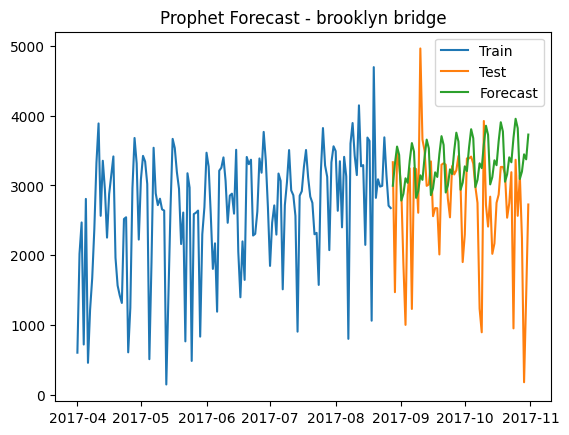

16:23:42 - cmdstanpy - INFO - Chain [1] start processing
16:23:42 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet for manhattan bridge

=== manhattan bridge ===
MAE: 1064.32, RMSE: 1566.60


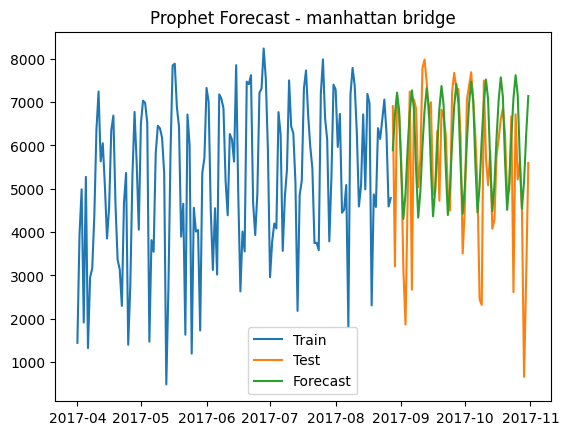

16:23:43 - cmdstanpy - INFO - Chain [1] start processing
16:23:43 - cmdstanpy - INFO - Chain [1] done processing


Running Prophet for williamsburg bridge

=== williamsburg bridge ===
MAE: 1080.61, RMSE: 1532.36


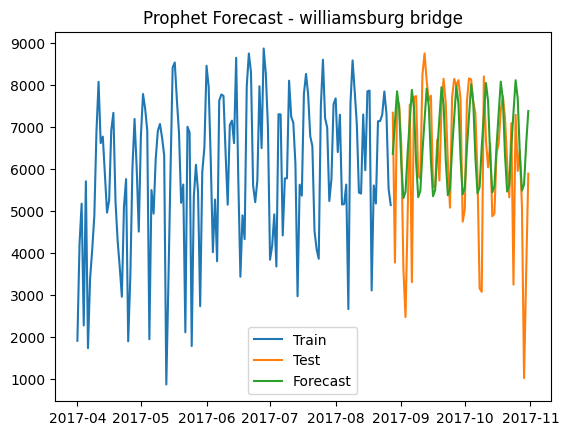

16:23:43 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet for queensboro bridge


16:23:43 - cmdstanpy - INFO - Chain [1] done processing



=== queensboro bridge ===
MAE: 912.44, RMSE: 1334.35


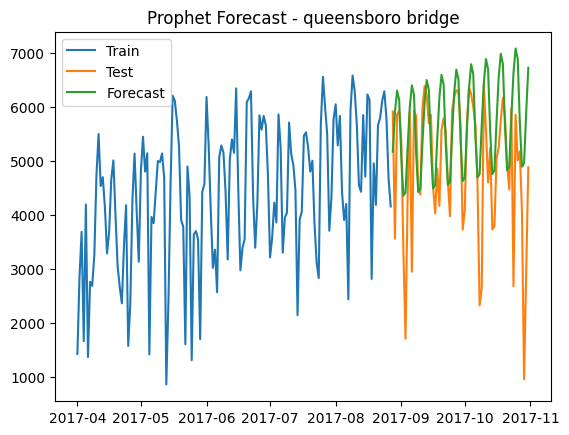

In [11]:
for bridge in bridges:
    print(f"Running Prophet for {bridge}")
    bridge_df = preprocess(df, bridge)
    run_prophet(bridge_df, bridge)